# Notebook 2: Modeling & Evaluation

Train logistic regression, scorecard (WoE + LR), XGBoost, and LightGBM. Compare ROC-AUC, precision-recall, and calibration.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from src.data_processing import TARGET_COL
from src.features import get_numeric_features, WoEEncoder
from src.models import (logistic_regression_pipeline, scorecard_logistic_regression,
                         xgboost_model, lightgbm_model)
from src.evaluation import (evaluate_model, plot_roc_curves, plot_pr_curves,
                              plot_calibration, risk_band_summary)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 2. Load Data & Split

In [2]:
df = pd.read_parquet('../data/processed/features.parquet')

FEATURES = get_numeric_features(df)
X = df[FEATURES]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Test default rate: {y_test.mean():.2%}")

Train: (119999, 15), Test: (30000, 15)
Test default rate: 6.68%


## 3. Baseline: Logistic Regression

In [3]:
lr_pipe = logistic_regression_pipeline()
lr_pipe.fit(X_train, y_train)
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]
lr_metrics = evaluate_model(y_test, lr_prob, 'Logistic Regression')
print(lr_metrics)

{'model': 'Logistic Regression', 'roc_auc': 0.8607250315005485, 'avg_precision': 0.3709698470341516, 'brier_score': 0.1451642157055104}


## 4. Scorecard Model (WoE + Logistic Regression)

WoE encoding transforms each feature bin into a numeric score contribution, producing a traditional banking scorecard.

In [4]:
woe = WoEEncoder(n_bins=10)
X_train_woe = woe.fit_transform(X_train, y_train)
X_test_woe  = woe.transform(X_test)

print("Information Value by feature:")
print(woe.iv_summary().to_string())

/Users/ryanchang/claude/credit-default-risk/src/features.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({"bin": bins, "y": y}).groupby("bin")["y"]
/Users/ryanchang/claude/credit-default-risk/src/features.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({"bin": bins, "y": y}).groupby("bin")["y"]
/Users/ryanchang/claude/credit-default-risk/src/features.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

Information Value by feature:
                                            IV
delinquency_severity                  1.283692
RevolvingUtilizationOfUnsecuredLines  1.109000
total_past_due_events                 1.047897
NumberOfTime30-59DaysPastDueNotWorse  0.466744
age                                   0.247928
DebtRatio                             0.070530
NumberOfOpenCreditLinesAndLoans       0.068437
MonthlyIncome                         0.066065
credit_line_density                   0.063585
NumberOfDependents                    0.024813
monthly_debt_est                      0.023753
NumberRealEstateLoansOrLines          0.013466
NumberOfTimes90DaysLate               0.000000
NumberOfTime60-89DaysPastDueNotWorse  0.000000
has_90day_late                        0.000000


In [5]:
sc_model = scorecard_logistic_regression()
sc_model.fit(X_train_woe, y_train)
sc_prob = sc_model.predict_proba(X_test_woe)[:, 1]
sc_metrics = evaluate_model(y_test, sc_prob, 'Scorecard (WoE + LR)')
print(sc_metrics)

{'model': 'Scorecard (WoE + LR)', 'roc_auc': 0.7649362216890352, 'avg_precision': 0.26914837499938615, 'brier_score': 0.23863582257878047}


## 5. XGBoost

In [6]:
xgb = xgboost_model()
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_metrics = evaluate_model(y_test, xgb_prob, 'XGBoost')
print(xgb_metrics)

{'model': 'XGBoost', 'roc_auc': 0.8694329812190367, 'avg_precision': 0.4033457594133318, 'brier_score': 0.08224886968337583}


## 6. LightGBM

In [7]:
lgbm = lightgbm_model()
lgbm.fit(X_train, y_train)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
lgbm_metrics = evaluate_model(y_test, lgbm_prob, 'LightGBM')
print(lgbm_metrics)

{'model': 'LightGBM', 'roc_auc': 0.8702285098113797, 'avg_precision': 0.40380919341710225, 'brier_score': 0.13948519907509319}


## 7. Model Comparison

In [8]:
results = pd.DataFrame([lr_metrics, sc_metrics, xgb_metrics, lgbm_metrics])
results = results.set_index('model').round(4)
print(results.to_string())

                      roc_auc  avg_precision  brier_score
model                                                    
Logistic Regression    0.8607         0.3710       0.1452
Scorecard (WoE + LR)   0.7649         0.2691       0.2386
XGBoost                0.8694         0.4033       0.0822
LightGBM               0.8702         0.4038       0.1395


## 8. ROC & Precision-Recall Curves

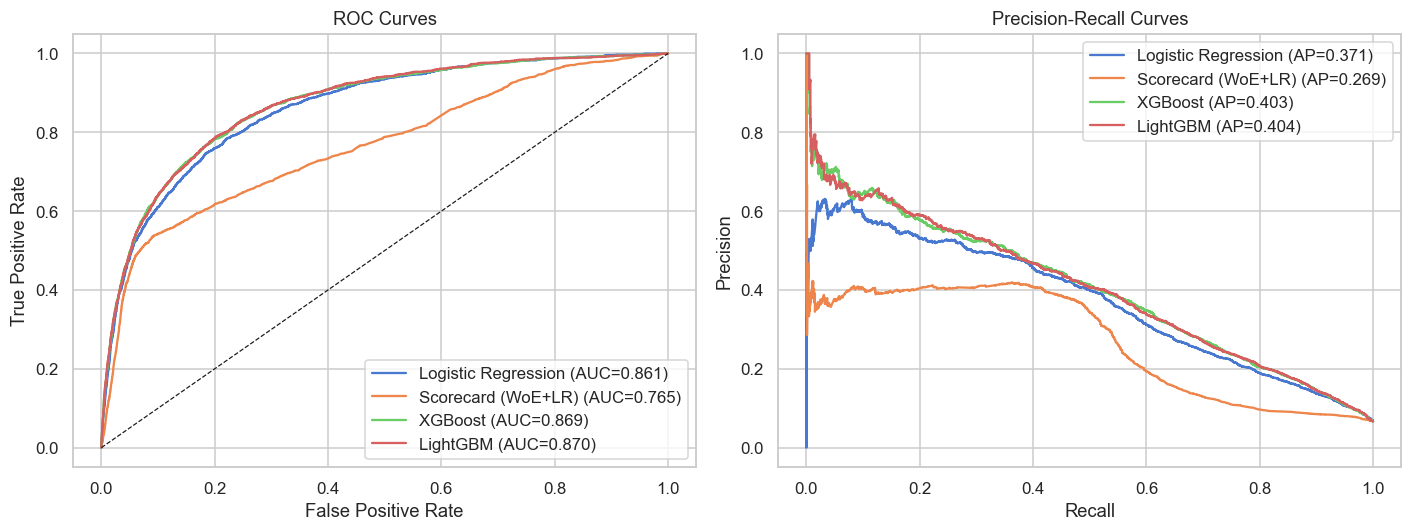

In [9]:
preds = {
    'Logistic Regression': lr_prob,
    'Scorecard (WoE+LR)': sc_prob,
    'XGBoost': xgb_prob,
    'LightGBM': lgbm_prob,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_roc_curves(preds, y_test, ax=axes[0])
plot_pr_curves(preds, y_test, ax=axes[1])
plt.tight_layout()
plt.savefig('../outputs/figures/roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 9. Calibration Plots

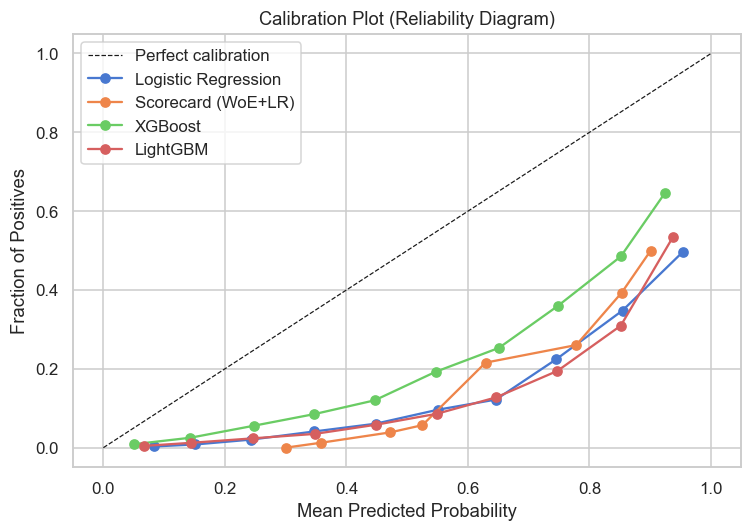

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_calibration(preds, y_test, ax=ax)
plt.tight_layout()
plt.savefig('../outputs/figures/calibration.png', bbox_inches='tight')
plt.show()

## 10. Risk Band Summary (XGBoost)

In [11]:
summary = risk_band_summary(y_test, xgb_prob)
print(summary.to_string(index=False))

risk_band  count  default_rate recommendation  pct_of_applicants
      Low  14405      0.008816        Approve          48.016667
   Medium   6967      0.031003  Manual Review          23.223333
     High   8628      0.192629        Decline          28.760000


/Users/ryanchang/claude/credit-default-risk/src/evaluation.py:82: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  return risk_band.map(mapping)


## 11. Save Models

In [12]:
import os
os.makedirs('../outputs/models', exist_ok=True)
joblib.dump(lr_pipe,  '../outputs/models/logistic_regression.pkl')
joblib.dump(sc_model, '../outputs/models/scorecard.pkl')
joblib.dump(xgb,      '../outputs/models/xgboost.pkl')
joblib.dump(lgbm,     '../outputs/models/lightgbm.pkl')
joblib.dump(woe,      '../outputs/models/woe_encoder.pkl')
print("Models saved.")

Models saved.
